# 🦆 Simulación del Juego Duck Hunt

**Curso:** Programación 101 — Maestría en Ciencia de Datos e IA (UTEC)
**Profesor:** Royer Rojas Malasquez

Este notebook implementa una simulación simplificada de *Duck Hunt* usando **NumPy** (matrices, aleatoriedad), **Pandas** (registro y análisis de disparos), **Matplotlib** (visualización del tablero) y **Seaborn** (gráficos estadísticos finales).

## Índice
1. Configuración inicial y constantes
2. Configuración de la partida (nombre, disparos, tamaño de grid)
3. Carga y preprocesamiento del fondo
4. Función `pato()`
5. Función `pistola()`
6. Validación de impacto (WINNER / GAME OVER)
7. Bucle principal del juego
8. Registro de resultados (CSV acumulado por jugador)
9. Visualización estadística final

> Este notebook se construye por etapas. Cada sección se revisa antes de avanzar a la siguiente.

## 1. Configuración inicial y constantes

Importamos las librerías obligatorias del proyecto y definimos las rutas hacia los recursos gráficos (`assets/`). Como el notebook vive dentro de `FinalProjectP101/`, las rutas son relativas a esa carpeta.

También definimos aquí la ruta del **CSV de registros históricos** (`registros_jugadores.csv`), donde se acumulan las partidas de todos los jugadores entre distintas ejecuciones del notebook.

In [50]:
# ============================================================
# LIBRERÍAS OBLIGATORIAS DEL PROYECTO
# ============================================================
import numpy as np                     # Matrices, cuadrículas y números aleatorios
import pandas as pd                     # Registro y análisis estadístico de disparos
import matplotlib.pyplot as plt         # Visualización del tablero e imágenes del juego
import seaborn as sns                   # Gráficos estadísticos finales

# ============================================================
# LIBRERÍAS DE APOYO (manejo de imágenes)
# ============================================================
from PIL import Image                   # Carga y manipulación de imágenes
from pathlib import Path                # Manejo de rutas de archivo multiplataforma
from matplotlib.patches import Rectangle  # Rectángulo de la mira (Sección 5)
from IPython.display import display

# ============================================================
# RUTAS DE RECURSOS (assets)
# ============================================================
# El notebook vive dentro de FinalProjectP101/, así que las rutas son relativas a esa carpeta.
RUTA_ASSETS = Path("assets")
RUTA_FONDO = RUTA_ASSETS / "paisaje-limpio (2).png"
RUTA_PATO = RUTA_ASSETS / "pato_limpio.png"  # versión ya sin fondo, ver Sección 4
RUTA_GANADOR = RUTA_ASSETS / "ganador.jpeg"
RUTA_GAMEOVER = RUTA_ASSETS / "gameover.jpg"
RUTA_CSV_REGISTROS = Path("registros_jugadores.csv")


def verificar_assets():
    """Valida que todos los recursos gráficos necesarios existan antes de continuar."""
    rutas = [RUTA_FONDO, RUTA_PATO, RUTA_GANADOR, RUTA_GAMEOVER]
    faltantes = [str(r) for r in rutas if not r.exists()]
    if faltantes:
        raise FileNotFoundError(
            "Faltan los siguientes recursos en 'assets/': " + ", ".join(faltantes)
        )
    print("✅ Todos los recursos gráficos fueron encontrados correctamente.")


verificar_assets()

✅ Todos los recursos gráficos fueron encontrados correctamente.


## 2. Configuración de la partida

Los 3 datos de la partida —nombre, número de disparos y tamaño de grid— se piden con `input()`, tal como pide el enunciado: *"El valor de n debe ser configurable"* (Sección "Sistema de Disparos"). `NUM_DISPAROS` y `TAM_GRID` son números, así que hay que convertir el texto que devuelve `input()` con `int(...)` antes de poder usarlos en comparaciones o rangos.

### Validar después de pedir los datos

`input()` siempre devuelve texto, y `int()` puede fallar si el jugador escribe algo que no es un número (por ejemplo, dejar la caja vacía o escribir letras). Por eso, después de leer los 3 valores, `validar_configuracion()` los revisa contra los rangos permitidos y avisa con un mensaje claro cuál está mal — en vez de que el programa falle más adelante, en una celda que no tiene nada que ver con la configuración.

In [51]:
# ============================================================
# BLOQUE A — LÍMITES PERMITIDOS
# ============================================================
GRID_MIN, GRID_MAX = 3, 8            # Límites del tamaño de grid (n x n)
DISPAROS_MIN, DISPAROS_MAX = 5, 99   # Límites del número de disparos


# ============================================================
# BLOQUE B — CONFIGURACIÓN DE LA PARTIDA (se pide por teclado)
# ============================================================
NOMBRE_JUGADOR = input("Nombre del jugador (solo letras, sin espacios): ").strip().upper()
NUM_DISPAROS = int(input(f"Número de disparos ({DISPAROS_MIN}-{DISPAROS_MAX}): "))
TAM_GRID = int(input(f"Tamaño del grid n x n ({GRID_MIN}-{GRID_MAX}): "))


# ============================================================
# BLOQUE C — VALIDACIÓN (buenas prácticas: fallar temprano y con un mensaje claro)
# ============================================================
def validar_configuracion(nombre, tam_grid, num_disparos):
    """Revisa los 3 parámetros de configuración. Lanza un error legible si alguno es inválido."""
    if not nombre.isalpha():
        raise ValueError(f"NOMBRE_JUGADOR={nombre!r} inválido: usa solo letras, sin espacios ni símbolos.")
    if not (GRID_MIN <= tam_grid <= GRID_MAX):
        raise ValueError(f"TAM_GRID={tam_grid} fuera de rango: debe estar entre {GRID_MIN} y {GRID_MAX}.")
    if not (DISPAROS_MIN <= num_disparos <= DISPAROS_MAX):
        raise ValueError(f"NUM_DISPAROS={num_disparos} fuera de rango: debe estar entre {DISPAROS_MIN} y {DISPAROS_MAX}.")


validar_configuracion(NOMBRE_JUGADOR, TAM_GRID, NUM_DISPAROS)
print(f"Configuración válida -- Jugador: {NOMBRE_JUGADOR} | Grid: {TAM_GRID}x{TAM_GRID} | Disparos: {NUM_DISPAROS}")

Configuración válida -- Jugador: JUGADOR | Grid: 4x4 | Disparos: 20


## 3. Carga y preprocesamiento del fondo

Cargamos `paisaje-limpio (2).png` como una matriz NumPy y la convertimos a **escala de grises** — el enunciado pide mostrar el fondo en blanco/negro o escala de grises, así que usamos escala de grises tanto para esta vista de comparación como para el tablero donde se juega. Luego dividimos el tablero en una cuadrícula `TAM_GRID x TAM_GRID` calculada dinámicamente.

### 3.1 Escala de grises: fórmula manual (explicación con ejemplo)

Una imagen a color es una matriz 3D `(alto, ancho, 3)` — el último eje son los canales **R, G, B**. Para convertirla a un solo canal de grises usamos la **fórmula de luminosidad**, que pondera cada canal según cuánto brillo percibe el ojo humano:

```
gris = 0.299·R + 0.587·G + 0.114·B
```

**Ejemplo numérico:** un píxel con `R=200, G=150, B=100`:

```
gris = 0.299×200 + 0.587×150 + 0.114×100
     = 59.8 + 88.05 + 11.4
     = 159.25  →  redondeado: 159
```

Con NumPy esto se aplica a **toda la imagen a la vez** (sin bucles) usando `np.dot(imagen[...,:3], [0.299, 0.587, 0.114])` — una multiplicación matricial que reduce el eje de 3 canales a 1.

### 3.2 División en grid (explicación con ejemplo)

Para dividir una imagen de `ancho=1920` px en `TAM_GRID=4` columnas, calculamos los **bordes** de cada celda con `np.linspace(0, ancho, columnas+1)`:

```
bordes_columna = [0, 480, 960, 1440, 1920]
```

Esto define 4 columnas: `[0-480)`, `[480-960)`, `[960-1440)`, `[1440-1920)`. La celda `(fila=i, columna=j)` del grid ocupa exactamente esa región de píxeles en la imagen original — así conectamos la matriz lógica del juego (índices `i,j`) con la matriz de píxeles real.

In [52]:
# ============================================================
# BLOQUE A — CARGA Y CONVERSIÓN DE IMAGEN (lógica pura, sin dibujar nada)
# ============================================================
PESOS_LUMINOSIDAD = np.array([0.299, 0.587, 0.114])  # pesos R, G, B


def cargar_fondo(ruta):
    """
    Carga una imagen desde disco y la devuelve como matriz NumPy RGB (alto, ancho, 3).
    Si la imagen tiene canal alfa (RGBA), se compone sobre un fondo blanco.
    """
    imagen = Image.open(ruta)

    if imagen.mode == "RGBA":
        fondo_blanco = Image.new("RGB", imagen.size, (255, 255, 255))
        fondo_blanco.paste(imagen, mask=imagen.split()[3])  # usa el canal alfa como máscara
        imagen = fondo_blanco
    else:
        imagen = imagen.convert("RGB")

    return np.array(imagen)


def convertir_a_grises(imagen_rgb):
    """
    Convierte una matriz RGB (alto, ancho, 3) a escala de grises (alto, ancho)
    aplicando la fórmula de luminosidad: 0.299 R + 0.587 G + 0.114 B
    """
    return np.dot(imagen_rgb[..., :3], PESOS_LUMINOSIDAD).astype(np.uint8)

In [47]:
# ============================================================
# BLOQUE B — ESTRUCTURA DEL GRID (matriz de bordes de celdas)
# ============================================================
def construir_bordes_grid(alto, ancho, filas, columnas):
    """
    Calcula los bordes en píxeles de cada celda de la cuadrícula.

    Devuelve dos arreglos NumPy:
      bordes_fila    -> shape (filas+1,)    posiciones verticales de los bordes
      bordes_columna -> shape (columnas+1,) posiciones horizontales de los bordes

    Ejemplo: alto=678, ancho=1920, filas=4, columnas=4
      bordes_columna = [0, 480, 960, 1440, 1920]
      bordes_fila    = [0, 169, 339, 508, 678]
    La celda (i, j) ocupa imagen[bordes_fila[i]:bordes_fila[i+1], bordes_columna[j]:bordes_columna[j+1]]
    """
    bordes_fila = np.linspace(0, alto, filas + 1, dtype=int)
    bordes_columna = np.linspace(0, ancho, columnas + 1, dtype=int)
    return bordes_fila, bordes_columna


def centro_celda(i, j, bordes_fila, bordes_columna):
    """Devuelve las coordenadas (x, y) en píxeles del centro de la celda (i, j), útil para dibujar sprites."""
    y = (bordes_fila[i] + bordes_fila[i + 1]) // 2
    x = (bordes_columna[j] + bordes_columna[j + 1]) // 2
    return x, y


def validar_posicion_celda(i, j, filas, columnas):
    """Verifica que (i, j) sea una posición válida dentro del grid filas x columnas."""
    return 0 <= i < filas and 0 <= j < columnas

In [ ]:
# ============================================================
# BLOQUE C — VISUALIZACIÓN DEL TABLERO (Matplotlib)
# ============================================================
def dibujar_tablero(ax, imagen, filas, columnas, titulo, cmap=None):
    """
    Dibuja 'imagen' en el eje 'ax' con las líneas de la cuadrícula y el número de cada celda superpuesto.
    """
    alto, ancho = imagen.shape[0], imagen.shape[1]
    bordes_fila, bordes_columna = construir_bordes_grid(alto, ancho, filas, columnas)

    ax.imshow(imagen, cmap=cmap, vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

    # Líneas de la cuadrícula
    for borde_y in bordes_fila:
        ax.axhline(borde_y, color="red", linewidth=1)
    for borde_x in bordes_columna:
        ax.axvline(borde_x, color="red", linewidth=1)

    # Número de celda (fila, columna) en el centro de cada casilla
    for i in range(filas):
        for j in range(columnas):
            x, y = centro_celda(i, j, bordes_fila, bordes_columna)
            ax.text(x, y, f"{i},{j}", color="yellow", fontsize=8,
                     ha="center", va="center", weight="bold")


def mostrar_fondo_grises(imagen_grises, filas, columnas):
    """Muestra el fondo en escala de grises con la cuadrícula superpuesta."""
    fig, ax = plt.subplots(figsize=(9, 9 * imagen_grises.shape[0] / imagen_grises.shape[1]))
    dibujar_tablero(ax, imagen_grises, filas, columnas, "Escala de grises", cmap="gray")
    plt.tight_layout()
    plt.show()


def dibujar_tablero_para_ronda(titulo=""):
    """
    Abre una figura nueva con el tablero de juego (escala de grises + grid) y devuelve (fig, ax)
    para que pato() y pistola() sigan dibujando ENCIMA de ese mismo eje --
    así el pato y la mira quedan en una sola imagen por ronda, en vez de una figura
    separada por cada cosa.
    """
    fig, ax = plt.subplots(figsize=(6, 6 * ALTO_IMG / ANCHO_IMG))
    ax.imshow(FONDO_GRISES, cmap="gray", vmin=0, vmax=255)
    for borde_y in BORDES_FILA:
        ax.axhline(borde_y, color="red", linewidth=1)
    for borde_x in BORDES_COLUMNA:
        ax.axvline(borde_x, color="red", linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, ANCHO_IMG)
    ax.set_ylim(ALTO_IMG, 0)
    ax.set_title(titulo, fontsize=11)
    return fig, ax

Fondo cargado: 1920x678 px  |  Grid: 4x4


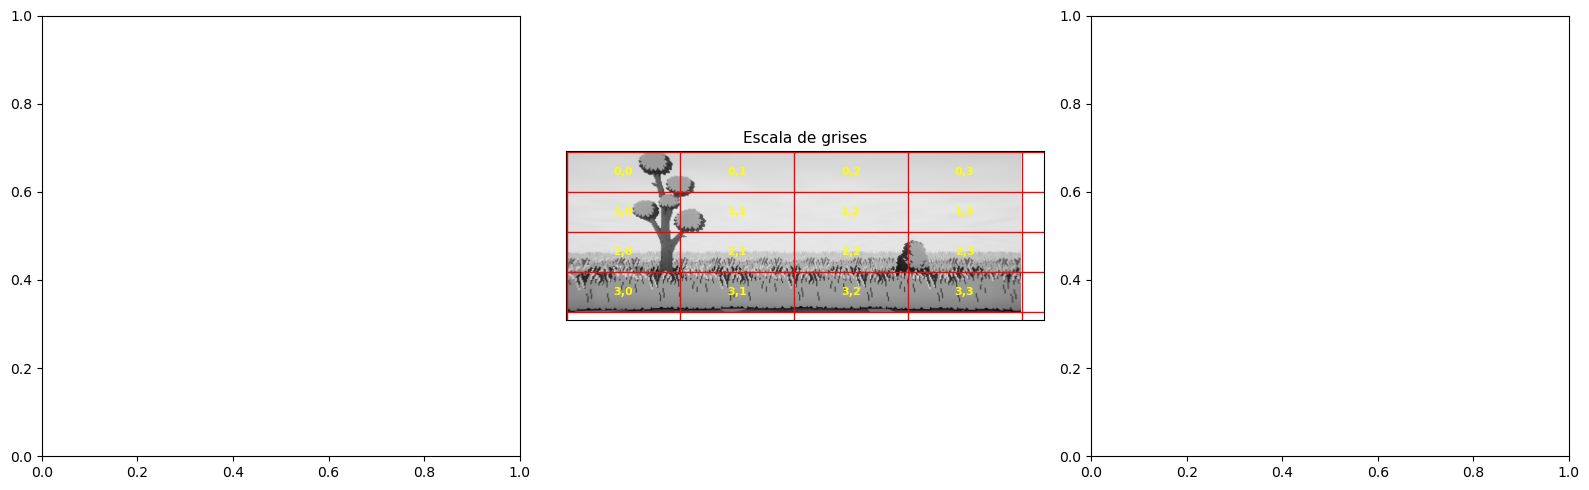

In [55]:
# ============================================================
# BLOQUE D — ORQUESTACIÓN: cargar, convertir y mostrar el tablero
# ============================================================
if TAM_GRID is None:
    raise RuntimeError(
        "TAM_GRID no está definido. Vuelve a la Sección 2 y ejecutá la celda de "
        "configuración antes de ejecutar esta celda."
    )

FONDO_COLOR = cargar_fondo(RUTA_FONDO)
FONDO_GRISES = convertir_a_grises(FONDO_COLOR)

ALTO_IMG, ANCHO_IMG = FONDO_GRISES.shape[0], FONDO_GRISES.shape[1]
BORDES_FILA, BORDES_COLUMNA = construir_bordes_grid(ALTO_IMG, ANCHO_IMG, TAM_GRID, TAM_GRID)

print(f"Fondo cargado: {ANCHO_IMG}x{ALTO_IMG} px  |  Grid: {TAM_GRID}x{TAM_GRID}")
mostrar_fondo_grises(FONDO_GRISES, TAM_GRID, TAM_GRID)

## 4. Función `pato()`

`pato()` debe: (1) elegir una celda al azar con NumPy, y (2) dibujar el sprite del pato sobre esa celda. Cada llamada reubica al pato dinámicamente — no hay ninguna opción de configuración para esto, es aleatorio en cada ronda.

### `imshow` ya compone la transparencia — no hace falta mezclar píxeles a mano

`ax.imshow(sprite, extent=[...])` dibuja el PNG como una capa más sobre los ejes, y Matplotlib respeta el canal alfa del sprite automáticamente al renderizarlo — donde el pato es transparente, se sigue viendo el fondo que ya estaba dibujado debajo. Solo hay que decirle **dónde** dibujarlo (`extent`), no **cómo mezclarlo**.

Para que esto funcione, el sprite necesita transparencia real. El archivo original `pato (1).png` no la tenía — tenía un fondo celeste sólido dibujado como parte de la imagen, no un canal alfa transparente. En vez de arreglarlo en cada ejecución del notebook, se preparó **una sola vez** una versión limpia (`assets/pato_limpio.png`) quitando ese fondo con chroma-key (comparar cada píxel contra el color de la esquina y volverlo transparente si es lo bastante parecido). El notebook ya carga directamente esa versión limpia.

### Ubicar el sprite dentro de una celda (`extent`)

`extent=[x0, x1, y1, y0]` le dice a `imshow` en qué rectángulo (en las mismas coordenadas del tablero) dibujar la imagen — se estira/encoge para llenar ese rectángulo, sin necesidad de redimensionar el sprite con PIL de antemano. Para que el pato no se deforme, calculamos el rectángulo más grande centrado en la celda que **conserva la proporción original** del sprite:

```
factor = mín(ancho_celda / ancho_sprite, alto_celda / alto_sprite) × escala
```

**Ejemplo:** una celda de `480×169` px y un sprite de `512×512` px (cuadrado): `factor = mín(480/512, 169/512) = mín(0.94, 0.33) = 0.33` — el lado que manda es el más chico (el alto de la celda), así el pato queda completo dentro de la celda sin recortarse ni estirarse.

In [ ]:
# ============================================================
# BLOQUE A — ALEATORIEDAD COMPARTIDA (pato y pistola la usan)
# ============================================================
def generar_posicion_aleatoria(filas, columnas):
    """Elige una celda (fila, columna) al azar dentro del grid, usando NumPy."""
    fila = np.random.randint(0, filas)
    columna = np.random.randint(0, columnas)
    return int(fila), int(columna)


# ============================================================
# BLOQUE B — DÓNDE DIBUJAR UN SPRITE DENTRO DE UNA CELDA
# ============================================================
def extent_celda(imagen, fila, columna, bordes_fila, bordes_columna, escala=1.0):
    """
    Calcula el rectángulo [x0, x1, y1, y0] (formato que espera imshow(extent=...)) donde hay
    que dibujar 'imagen' para que quede centrada en la celda (fila, columna), conservando su
    proporción original y ocupando como máximo 'escala' de esa celda.
    """
    y0, y1 = bordes_fila[fila], bordes_fila[fila + 1]
    x0, x1 = bordes_columna[columna], bordes_columna[columna + 1]
    alto_img, ancho_img = imagen.shape[0], imagen.shape[1]

    factor = min((x1 - x0) / ancho_img, (y1 - y0) / alto_img) * escala
    ancho, alto = ancho_img * factor, alto_img * factor

    x_centro, y_centro = centro_celda(fila, columna, bordes_fila, bordes_columna)
    return [x_centro - ancho / 2, x_centro + ancho / 2, y_centro + alto / 2, y_centro - alto / 2]

In [ ]:
# ============================================================
# BLOQUE C — SPRITE DEL PATO (se carga una sola vez, no en cada ronda)
# ============================================================
ESCALA_PATO = 0.8  # el pato ocupa como máximo el 80% de la celda, para dejarle un margen

SPRITE_PATO = np.array(Image.open(RUTA_PATO).convert("RGBA"))
print(f"Sprite del pato cargado: {SPRITE_PATO.shape[1]}x{SPRITE_PATO.shape[0]} px")


# ============================================================
# BLOQUE D — FUNCIÓN pato()
# ============================================================
def pato(ax, bordes_fila=BORDES_FILA, bordes_columna=BORDES_COLUMNA):
    """
    Genera una posición aleatoria dentro del grid (NumPy) y dibuja el pato en esa celda,
    sobre el eje 'ax' ya abierto. Devuelve la posición elegida (fila, columna).
    """
    fila, columna = generar_posicion_aleatoria(TAM_GRID, TAM_GRID)
    extent = extent_celda(SPRITE_PATO, fila, columna, bordes_fila, bordes_columna, ESCALA_PATO)
    ax.imshow(SPRITE_PATO, extent=extent, zorder=3)
    return fila, columna


# --- Prueba de la función pato() ---
fig, ax = dibujar_tablero_para_ronda("Prueba de pato()")
posicion_pato_demo = pato(ax)
ax.set_xlim(0, ANCHO_IMG)
ax.set_ylim(ALTO_IMG, 0)
plt.show()
print("Posición del pato (demo):", posicion_pato_demo)

## 5. Función `pistola()`

`pistola()` debe: (1) elegir una celda de impacto al azar con NumPy (reutilizando `generar_posicion_aleatoria()` de la Sección 4), y (2) marcar esa celda con una mira.

### Mira simple: un rectángulo + una marca "x"

Una versión anterior calculaba un círculo a mano con trigonometría (100 puntos con `cos`/`sin`). No hace falta: Matplotlib ya trae las piezas para esto.

- **`Rectangle`** (de `matplotlib.patches`) dibuja el borde de la celda completa — se le da la esquina inferior-izquierda `(x0, y0)` y el ancho/alto de la celda, con `fill=False` para que solo se vea el borde.
- **`ax.plot(x, y, marker="x")`** dibuja una marca "x" en el centro de la celda — `marker="x"` es un símbolo que Matplotlib ya trae incorporado, no hay que construirlo con puntos.

Es la misma idea de "marcar una celda" que antes, con menos código y usando piezas ya hechas de la librería en vez de reinventarlas.

In [ ]:
# ============================================================
# BLOQUE A — FUNCIÓN pistola()
# ============================================================
COLOR_MIRA = "red"
GROSOR_MIRA = 2.5
TAM_MARCA_X = 16


def pistola(ax, bordes_fila=BORDES_FILA, bordes_columna=BORDES_COLUMNA):
    """
    Genera una posición de impacto aleatoria dentro del grid (NumPy) y dibuja una mira
    (rectángulo + marca "x") sobre el eje 'ax' ya abierto. Devuelve la posición (fila, columna).
    """
    fila, columna = generar_posicion_aleatoria(TAM_GRID, TAM_GRID)

    y0, y1 = bordes_fila[fila], bordes_fila[fila + 1]
    x0, x1 = bordes_columna[columna], bordes_columna[columna + 1]
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                            edgecolor=COLOR_MIRA, linewidth=GROSOR_MIRA, zorder=4))

    x_centro, y_centro = centro_celda(fila, columna, bordes_fila, bordes_columna)
    ax.plot(x_centro, y_centro, marker="x", color=COLOR_MIRA,
             markersize=TAM_MARCA_X, markeredgewidth=GROSOR_MIRA, zorder=5)

    return fila, columna


# --- Prueba de la función pistola() ---
fig, ax = dibujar_tablero_para_ronda("Prueba de pistola()")
posicion_disparo_demo = pistola(ax)
ax.set_xlim(0, ANCHO_IMG)
ax.set_ylim(ALTO_IMG, 0)
plt.show()
print("Posición del disparo (demo):", posicion_disparo_demo)

## 6. Validación de impacto (WINNER / GAME OVER)

Comparamos la posición del pato (`pato()`) contra la del disparo (`pistola()`). Si coinciden → **acierto**: pantalla `ganador.jpeg` con texto **WINNER**. Si no coinciden → **fallo**: pantalla `gameover.jpg` con texto **GAME OVER** en rojo. En ambos casos se registra el resultado del disparo para las estadísticas finales (Sección 8).

> Recordatorio del flujo acordado: esto ocurre **en cada uno de los `NUM_DISPAROS` disparos** — el juego no se corta en el primer fallo, siempre se completan todos los disparos configurados. El resumen agregado va aparte, al final (Sección 7).

### 6.1 Comparar posiciones

Cada posición es una tupla `(fila, columna)`. En Python, comparar tuplas con `==` compara elemento por elemento automáticamente: `(2, 3) == (2, 3)` → `True`, `(2, 3) == (2, 1)` → `False`. No hace falta comparar `fila` y `columna` por separado.

In [ ]:
# ============================================================
# BLOQUE C — PANTALLA DE REACCIÓN A PANTALLA COMPLETA (WINNER / GAME OVER)
# ============================================================
import matplotlib.patheffects as path_effects  # contorno del texto, para que se lea sobre cualquier fondo


def mostrar_pantalla_reaccion(ruta_imagen, texto, color_texto):
    """Muestra 'ruta_imagen' a pantalla completa con 'texto' grande centrado (con contorno negro)."""
    imagen = np.array(Image.open(ruta_imagen).convert("RGB"))
    alto, ancho = imagen.shape[0], imagen.shape[1]

    fig, ax = plt.subplots(figsize=(6, 6 * alto / ancho))
    ax.imshow(imagen)
    ax.set_xticks([])
    ax.set_yticks([])

    texto_dibujado = ax.text(
        ancho / 2, alto / 2, texto,
        color=color_texto, fontsize=42, weight="bold",
        ha="center", va="center",
    )
    texto_dibujado.set_path_effects([
        path_effects.Stroke(linewidth=4, foreground="black"),
        path_effects.Normal(),
    ])

    plt.show()

In [ ]:
# ============================================================
# BLOQUE C — VALIDACIÓN DE IMPACTO Y REGISTRO DEL DISPARO
# ============================================================
def validar_impacto(posicion_pato, posicion_disparo):
    """Compara la posición del pato y la del disparo. True si coinciden (acierto)."""
    return posicion_pato == posicion_disparo


def procesar_disparo(numero_disparo, posicion_pato, posicion_disparo):
    """Valida el impacto y arma el registro (dict) del disparo para las estadísticas."""
    acierto = validar_impacto(posicion_pato, posicion_disparo)
    return {
        "disparo_num": numero_disparo,
        "jugador": NOMBRE_JUGADOR,
        "pato_fila": posicion_pato[0],
        "pato_columna": posicion_pato[1],
        "disparo_fila": posicion_disparo[0],
        "disparo_columna": posicion_disparo[1],
        "acierto": acierto,
    }


# --- Prueba de procesar_disparo(): forzamos un acierto y un fallo para ver ambos casos ---
registro_demo_acierto = procesar_disparo(1, posicion_pato=(1, 1), posicion_disparo=(1, 1))
if registro_demo_acierto["acierto"]:
    mostrar_pantalla_reaccion(RUTA_GANADOR, "WINNER", "lime")

registro_demo_fallo = procesar_disparo(2, posicion_pato=(0, 0), posicion_disparo=(2, 2))
if not registro_demo_fallo["acierto"]:
    mostrar_pantalla_reaccion(RUTA_GAMEOVER, "GAME OVER", "red")

print(registro_demo_acierto)
print(registro_demo_fallo)

## 7. Bucle principal del juego

Repetimos el ciclo `pato()` → `pistola()` → `procesar_disparo()` exactamente `NUM_DISPAROS` veces (la variable configurada en la Sección 2), sin cortar el juego aunque el jugador falle — tal como se definió: **todos** los disparos se juegan siempre, y cada uno queda registrado para las estadísticas finales.

Cada ronda abre **un solo tablero** (`dibujar_tablero_para_ronda()`) y dibuja el pato y la mira encima del mismo eje -- así se ven juntos en una imagen. Después se muestra la pantalla de reacción (WINNER o GAME OVER) a pantalla completa.

Cada registro (un dict por disparo) se guarda en una lista; al terminar la partida, esa lista se convierte en una tabla de pandas en la Sección 8.

> ⚠️ **Nota:** con el `NUM_DISPAROS` configurado (por defecto 20), esta celda genera dos figuras por disparo (el tablero de la ronda + la pantalla de reacción). Es intencional — el enunciado pide visualizar cada paso — pero puede tardar unos segundos en ejecutarse por completo.

In [ ]:
# ============================================================
# BLOQUE A — BUCLE PRINCIPAL DEL JUEGO
# ============================================================
def jugar_partida():
    """
    Ejecuta la partida completa: por cada uno de los NUM_DISPAROS disparos configurados,
    abre un tablero nuevo, hace aparecer un pato, dispara, valida el impacto y muestra la
    reacción a pantalla completa. Devuelve la lista de registros (un dict por disparo).
    """
    registros = []
    for numero_disparo in range(1, NUM_DISPAROS + 1):
        print(f"\n=== Disparo {numero_disparo}/{NUM_DISPAROS} ===")

        fig, ax = dibujar_tablero_para_ronda(f"Disparo {numero_disparo}/{NUM_DISPAROS}")
        posicion_pato = pato(ax)
        posicion_disparo = pistola(ax)
        ax.set_xlim(0, ANCHO_IMG)
        ax.set_ylim(ALTO_IMG, 0)
        plt.show()

        registro = procesar_disparo(numero_disparo, posicion_pato, posicion_disparo)
        if registro["acierto"]:
            mostrar_pantalla_reaccion(RUTA_GANADOR, "WINNER", "lime")
        else:
            mostrar_pantalla_reaccion(RUTA_GAMEOVER, "GAME OVER", "red")

        registros.append(registro)
    return registros


# ============================================================
# BLOQUE B — ORQUESTACIÓN: jugar la partida completa
# ============================================================
REGISTROS_PARTIDA = jugar_partida()
print(f"\nPartida terminada: {len(REGISTROS_PARTIDA)} disparos registrados para {NOMBRE_JUGADOR}.")

## 8. Pantalla final, estadísticas y registro en CSV

Con `REGISTROS_PARTIDA` (lista de dicts, uno por disparo) armamos un **DataFrame de pandas**, calculamos el resumen (`total`, `exitosos`, `errados`, `% aciertos`, `% fallos`) y mostramos la **pantalla final** reutilizando `gameover.jpg` — esta vez con el resumen de la partida superpuesto, para distinguirla claramente de la reacción de "fallo" de cada disparo individual (Sección 6).

Finalmente, agregamos una fila al **CSV histórico** (`registros_jugadores.csv`). Como se abre en modo `"a"` (append), cada partida de cada jugador se acumula sin borrar las anteriores — así se arma el registro multi-jugador para la Sección 9.

In [ ]:
# ============================================================
# BLOQUE A — ESTADÍSTICAS DE LA PARTIDA (pandas)
# ============================================================
def calcular_estadisticas(df_partida):
    """Calcula el resumen estadístico (total, exitosos, errados, %) a partir del DataFrame de disparos."""
    total = len(df_partida)
    exitosos = int(df_partida["acierto"].sum())
    errados = total - exitosos
    porcentaje_aciertos = round(100 * exitosos / total, 1) if total else 0.0
    porcentaje_fallos = round(100 * errados / total, 1) if total else 0.0

    return {
        "jugador": NOMBRE_JUGADOR,
        "grid": f"{TAM_GRID}x{TAM_GRID}",
        "total_disparos": total,
        "disparos_exitosos": exitosos,
        "disparos_errados": errados,
        "porcentaje_aciertos": porcentaje_aciertos,
        "porcentaje_fallos": porcentaje_fallos,
    }


# ============================================================
# BLOQUE B — PANTALLA FINAL (reutiliza gameover.jpg, resumen superpuesto)
# ============================================================
def mostrar_pantalla_final(estadisticas):
    """Muestra la pantalla de fin de partida (gameover.jpg) con el resumen estadístico superpuesto."""
    imagen = np.array(Image.open(RUTA_GAMEOVER).convert("RGB"))
    alto, ancho = imagen.shape[0], imagen.shape[1]

    fig, ax = plt.subplots(figsize=(6, 6 * alto / ancho))
    ax.imshow(imagen)
    ax.set_xticks([])
    ax.set_yticks([])

    titulo = ax.text(ancho / 2, alto * 0.20, "FIN DE LA PARTIDA", color="white",
                      fontsize=24, weight="bold", ha="center", va="center")
    titulo.set_path_effects([path_effects.Stroke(linewidth=4, foreground="black"), path_effects.Normal()])

    texto_stats = (
        f"Jugador: {estadisticas['jugador']}\n"
        f"Grid: {estadisticas['grid']}\n"
        f"Disparos: {estadisticas['total_disparos']}\n"
        f"Aciertos: {estadisticas['disparos_exitosos']} ({estadisticas['porcentaje_aciertos']}%)\n"
        f"Fallos: {estadisticas['disparos_errados']} ({estadisticas['porcentaje_fallos']}%)"
    )
    cuerpo = ax.text(ancho / 2, alto * 0.62, texto_stats, color="yellow",
                      fontsize=13, weight="bold", ha="center", va="center", linespacing=1.8)
    cuerpo.set_path_effects([path_effects.Stroke(linewidth=3, foreground="black"), path_effects.Normal()])

    plt.show()


# ============================================================
# BLOQUE C — REGISTRO EN CSV HISTÓRICO
# ============================================================
def guardar_registro_csv(estadisticas, ruta_csv=RUTA_CSV_REGISTROS):
    """Agrega una fila con las estadísticas de esta partida al CSV histórico (lo crea si no existe)."""
    fila = pd.DataFrame([{**estadisticas, "fecha_hora": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}])
    escribir_encabezado = not ruta_csv.exists()
    fila.to_csv(ruta_csv, mode="a", header=escribir_encabezado, index=False, encoding="utf-8")
    print(f"✅ Registro guardado en '{ruta_csv}' (partida de {estadisticas['jugador']}).")

In [ ]:
# ============================================================
# BLOQUE D — ORQUESTACIÓN: armar la tabla, mostrar resumen y guardar
# ============================================================
if not REGISTROS_PARTIDA:
    raise RuntimeError(
        "REGISTROS_PARTIDA está vacío. Vuelve a la Sección 7 y ejecuta jugar_partida() "
        "antes de continuar."
    )

DF_PARTIDA = pd.DataFrame(REGISTROS_PARTIDA)
ESTADISTICAS_PARTIDA = calcular_estadisticas(DF_PARTIDA)

print("Tabla de disparos de la partida:")
display(DF_PARTIDA)

print("\nResumen estadístico:")
display(pd.DataFrame([ESTADISTICAS_PARTIDA]))

mostrar_pantalla_final(ESTADISTICAS_PARTIDA)
guardar_registro_csv(ESTADISTICAS_PARTIDA)

## 9. Visualización estadística final

Cerramos el proyecto con gráficos estadísticos usando `pandas` + `Matplotlib` + `Seaborn`, y una tabla comparativa (*leaderboard*) armada a partir del CSV histórico acumulado entre partidas.

- **Barras:** cantidad de aciertos vs. fallos de esta partida.
- **Pie chart:** proporción de aciertos/fallos.
- **Heatmap:** en qué celdas del grid apareció el pato con más frecuencia — reutiliza la matriz `TAM_GRID x TAM_GRID` como estructura de conteo.
- **Leaderboard:** todas las partidas registradas en `registros_jugadores.csv` (de todos los jugadores), ordenadas por % de aciertos.

In [ ]:
# ============================================================
# BLOQUE A — PREPARACIÓN DE DATOS PARA LOS GRÁFICOS
# ============================================================
sns.set_theme(style="whitegrid")  # estilo consistente para todos los gráficos de Seaborn/Matplotlib


def construir_matriz_frecuencia_pato(df_partida, tam_grid):
    """Cuenta cuántas veces apareció el pato en cada celda (fila, columna) del grid."""
    matriz = np.zeros((tam_grid, tam_grid), dtype=int)
    np.add.at(matriz, (df_partida["pato_fila"], df_partida["pato_columna"]), 1)
    return matriz


MATRIZ_FRECUENCIA_PATO = construir_matriz_frecuencia_pato(DF_PARTIDA, TAM_GRID)

In [ ]:
# ============================================================
# BLOQUE B — GRÁFICOS ESTADÍSTICOS (barras, pie, heatmap)
# ============================================================
def graficar_barras_resultado(ax, df_partida):
    """Gráfico de barras: cantidad de disparos exitosos vs. errados."""
    conteo = df_partida["acierto"].map({True: "Acierto", False: "Fallo"}).value_counts()
    sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index,
                palette={"Acierto": "seagreen", "Fallo": "indianred"}, legend=False, ax=ax)
    ax.set_title("Aciertos vs. fallos")
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de disparos")


def graficar_pie_resultado(ax, estadisticas):
    """Pie chart: proporción de aciertos vs. fallos."""
    valores = [estadisticas["disparos_exitosos"], estadisticas["disparos_errados"]]
    etiquetas = [f"Aciertos ({estadisticas['porcentaje_aciertos']}%)",
                 f"Fallos ({estadisticas['porcentaje_fallos']}%)"]
    ax.pie(valores, labels=etiquetas, colors=["seagreen", "indianred"],
           autopct=lambda p: f"{p:.0f}%" if p > 0 else "", startangle=90)
    ax.set_title("Proporción de aciertos")


def graficar_heatmap_posiciones(ax, matriz_frecuencia):
    """Heatmap: frecuencia con la que el pato apareció en cada celda del grid."""
    sns.heatmap(matriz_frecuencia, annot=True, fmt="d", cmap="Reds", cbar=True, ax=ax)
    ax.set_title("Frecuencia de aparición del pato por celda")
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")


fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
graficar_barras_resultado(ejes[0], DF_PARTIDA)
graficar_pie_resultado(ejes[1], ESTADISTICAS_PARTIDA)
graficar_heatmap_posiciones(ejes[2], MATRIZ_FRECUENCIA_PATO)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOQUE C — LEADERBOARD HISTÓRICO (todas las partidas registradas en el CSV)
# ============================================================
def cargar_historial(ruta_csv=RUTA_CSV_REGISTROS):
    """Carga el CSV histórico de partidas. Si todavía no existe, devuelve un DataFrame vacío."""
    if not ruta_csv.exists():
        return pd.DataFrame()
    return pd.read_csv(ruta_csv)


def mostrar_leaderboard(historial):
    """Muestra la tabla de partidas ordenada por % de aciertos, y un gráfico de barras comparativo."""
    if historial.empty:
        print("Todavía no hay partidas registradas en el historial.")
        return

    leaderboard = historial.sort_values("porcentaje_aciertos", ascending=False).reset_index(drop=True)
    print("Historial de partidas (todas las jugadoras y jugadores registrados):")
    display(leaderboard)

    etiquetas = leaderboard["jugador"] + " (" + leaderboard["fecha_hora"].str.slice(0, 16) + ")"
    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(leaderboard))))
    sns.barplot(x=leaderboard["porcentaje_aciertos"], y=etiquetas, hue=etiquetas,
                palette="viridis", legend=False, ax=ax)
    ax.set_title("Leaderboard — % de aciertos por partida")
    ax.set_xlabel("% de aciertos")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


HISTORIAL_PARTIDAS = cargar_historial()
mostrar_leaderboard(HISTORIAL_PARTIDAS)